In [8]:
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, MaxPool2D, Flatten, Dropout
from keras.utils import plot_model,to_categorical
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
train_datagen = ImageDataGenerator(rescale=1/255, zoom_range=0.2,
                                   horizontal_flip = True, shear_range = 0.2)

In [10]:
train = train_datagen.flow_from_directory(
    'D:/Downloads/imagenet-new/train',
    class_mode = 'categorical',
    target_size = (64,64),
  
)

Found 5000 images belonging to 10 classes.


In [11]:
train.class_indices

{'crocodile': 0,
 'fish': 1,
 'fossils': 2,
 'frog': 3,
 'insect': 4,
 'reptiles': 5,
 'scorpion': 6,
 'snake': 7,
 'spider': 8,
 'toad': 9}

In [12]:
model = Sequential()

model.add(Input(shape = (64,64,3)))

model.add(Conv2D(64, (3,3), activation = 'relu'))
model.add(MaxPool2D(2,2))

model.add(Conv2D(32, (3,3), activation = 'relu'))
model.add(MaxPool2D(2,2))


model.add(Flatten())

model.add(Dense(32, activation = 'relu'))
model.add(Dense(10, activation = 'sigmoid'))


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       200,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,322 (864.54 KB)

 Trainable params: 221,322 (864.54 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(loss= 'sparse_categorical_crossentropy',optimizer= 'adam', metrics=['accuracy'])

Predict the class of an image

In [16]:
result = dict((v,k) for k,v in train.class_indices.items())
result

{0: 'crocodile',
 1: 'fish',
 2: 'fossils',
 3: 'frog',
 4: 'insect',
 5: 'reptiles',
 6: 'scorpion',
 7: 'snake',
 8: 'spider',
 9: 'toad'}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


'fish'

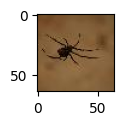

In [19]:
img = plt.imread('D:/Downloads/imagenet-new/val/images/val_192.JPEG')
plt.figure(figsize=(1,1))
plt.imshow(img)
img = img.reshape(1,64,64,3)
pred = model.predict(img)
result[pred.argmax()]